In [2]:
!pip install netcdf4 h5netcdf

In [3]:
import sys
!{sys.executable} -m pip install netcdf4 h5netcdf

In [4]:
import sys
# Forzamos la actualización de xarray y dask para corregir los metadatos de versión
!{sys.executable} -m pip install --upgrade xarray dask packaging netcdf4

In [5]:
#OPEN NETCDF FILES
from netCDF4 import Dataset
import numpy as np
import xarray as xr

# Reading in the netCDF file 
file_in = Dataset("TSM_1998_2017_UNIDO.nc")
# Displaying the names of the variables
print(file_in.variables)

{'sst': <class 'netCDF4.Variable'>
float32 sst(valid_time, latitude, longitude)
    _FillValue: nan
    GRIB_paramId: 34
    GRIB_dataType: an
    GRIB_numberOfPoints: 221
    GRIB_typeOfLevel: surface
    GRIB_stepUnits: 1
    GRIB_stepType: instant
    GRIB_gridType: regular_ll
    GRIB_uvRelativeToGrid: 0
    GRIB_NV: 0
    GRIB_Nx: 13
    GRIB_Ny: 17
    GRIB_cfName: unknown
    GRIB_cfVarName: sst
    GRIB_gridDefinitionDescription: Latitude/Longitude Grid
    GRIB_iDirectionIncrementInDegrees: 0.25
    GRIB_iScansNegatively: 0
    GRIB_jDirectionIncrementInDegrees: 0.25
    GRIB_jPointsAreConsecutive: 0
    GRIB_jScansPositively: 0
    GRIB_latitudeOfFirstGridPointInDegrees: 5.0
    GRIB_latitudeOfLastGridPointInDegrees: 1.0
    GRIB_longitudeOfFirstGridPointInDegrees: -80.0
    GRIB_longitudeOfLastGridPointInDegrees: -77.0
    GRIB_missingValue: 3.4028234663852886e+38
    GRIB_name: Sea surface temperature
    GRIB_shortName: sst
    GRIB_units: K
    long_name: Sea surface temp

In [6]:
import pandas as pd
import numpy as np
import os
from netCDF4 import Dataset, num2date

In [7]:
archivos = [
    'PUNTO1',
    'PUNTO 11'
    ]
all_rows = []
for archivo in archivos:
    file_in = Dataset("TSM_1998_2017_UNIDO_v2.nc")
#Extraer variables
lat_data = file_in.variables['latitude'][:]
lon_data = file_in.variables['longitude'][:]
evp_data = file_in.variables['sst'][:]
time_data = file_in.variables['valid_time'][:]

In [8]:
# Convertir tiempo
t_unit = file_in.variables['valid_time'].units
t_cal = file_in.variables['valid_time'].calendar
time_values = num2date(time_data, units=t_unit, calendar=t_cal)
time_strings = [t.strftime("%Y-%m-%d %H:%M") for t in time_values]

In [9]:

    for t_index, time in enumerate(time_strings):
        for lat_index, lat in enumerate(lat_data):
            for lon_index, lon in enumerate(lon_data):
                value = evp_data[t_index, lat_index, lon_index]
                all_rows.append([time, lat, lon, value])

In [10]:
import pandas as pd
import os
import numpy as np

# Instead of creating one large DataFrame, process in chunks
chunk_size = 100000  # Adjust based on your memory constraints

# Create an empty CSV file first
current_dir = os.path.dirname(os.path.abspath("__file__"))
csv_output_path = os.path.join(current_dir, "SST.csv")

# Write header
pd.DataFrame(columns=["Date", "Latitude", "Longitude", "Sea surface t"]).to_csv(csv_output_path, index=False)

# Process data in chunks
for i in range(0, len(all_rows), chunk_size):
    chunk = all_rows[i:i+chunk_size]
    chunk_df = pd.DataFrame(chunk, columns=["Date", "Latitude", "Longitude", "Sea surface t"])
    
    # Append to CSV without writing the header again
    chunk_df.to_csv(csv_output_path, mode='a', header=False, index=False)
    
    # Free memory
    del chunk_df
    
print(f"Datos exportados a {csv_output_path} como CSV.")

Datos exportados a C:\Users\danna\INSTRUGEO\SST.csv como CSV.


In [11]:
#media mensual de la SST
import pandas as pd

# Leer el archivo CSV con datos diarios
data = pd.read_csv(r"C:\Users\danna\INSTRUGEO\SST.csv")

In [12]:
# columna de temperatura es numérica?
data['Sea surface t'] = pd.to_numeric(data['Sea surface t'], errors='coerce')
#Kelvin a Celsius
data['Sea surface t'] = data['Sea surface t'] - 273.15
#'Date' a formato datetime
data['Date'] = pd.to_datetime(data['Date'])

#Mes y año
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month

#Media mensual
monthly_means = data.groupby(['Month'])['Sea surface t'].mean().reset_index()
monthly_means.rename(columns={'Sea surface t': 'Media Temperatura'}, inplace=True)

In [13]:
#Como se ve?
print(data.head(5))
print(monthly_means.head(12))

        Date  Latitude  Longitude  Sea surface t  Year  Month
0 1998-01-01       5.0     -80.00       28.12075  1998      1
1 1998-01-01       5.0     -79.75       28.15493  1998      1
2 1998-01-01       5.0     -79.50       28.22330  1998      1
3 1998-01-01       5.0     -79.25       28.35122  1998      1
4 1998-01-01       5.0     -79.00       28.38247  1998      1
    Month  Media Temperatura
0       1          26.874421
1       2          26.539431
2       3          26.174300
3       4          27.094187
4       5          27.662061
5       6          27.243141
6       7          27.212191
7       8          27.122175
8       9          27.144510
9      10          27.181779
10     11          26.901266
11     12          26.779858


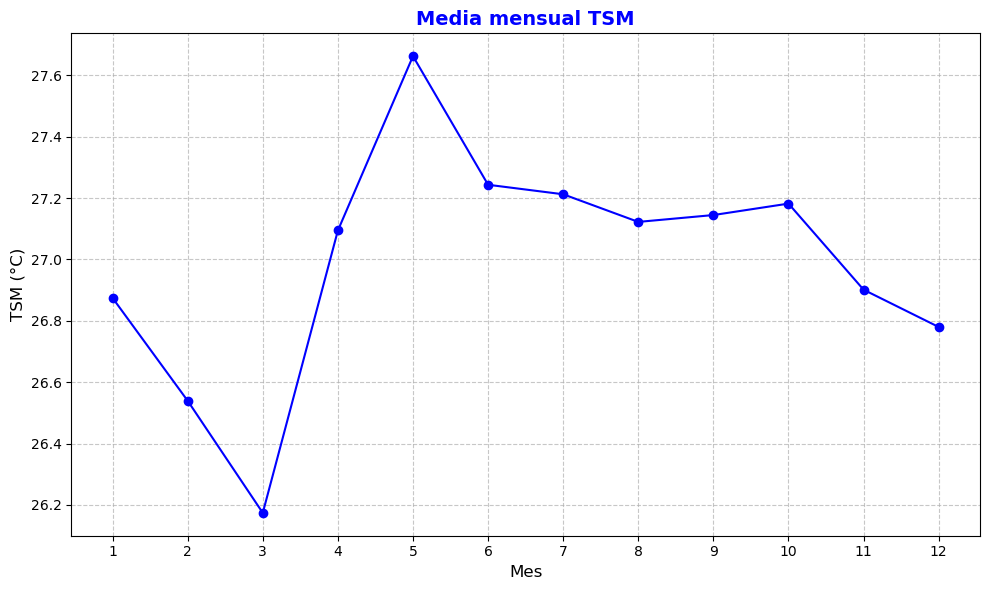

<Figure size 640x480 with 0 Axes>

In [14]:
import matplotlib.pyplot as plt

# Crear la figura donde se va a dibujar la gráfica
plt.figure(figsize=(10, 6))

# Graficar la temperatura media mensual usando los datos calculados previamente
plt.plot(
    monthly_means['Month'], 
    monthly_means['Media Temperatura'], 
    marker='o',           # Marca cada punto mensual
    linestyle='-',        # Línea continua
    color='b'             # Color azul
)

# Configurar título y etiquetas de los ejes
plt.title(f'Media mensual TSM', fontsize=14, color='blue',fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('TSM (°C)', fontsize=12)

# Asegurar que se muestren todos los meses (1 a 12) en el eje X
plt.xticks(range(1, 13))

# Activar la cuadrícula para mejor visualización
plt.grid(True, linestyle='--', alpha=0.7)

# Ajustar automáticamente los márgenes de la figura
plt.tight_layout()
plt.show()
plt.savefig("MediamTSM.png")

In [15]:
# Ver los primeros 50 datos de los promedios mensuales
monthly_means.head(50)

# Sacar todas las combinaciones únicas de latitud y longitud
# ver qué puntos diferentes hay en el mapa
unique_locations = data[['Latitude', 'Longitude']].drop_duplicates().reset_index(drop=True)

print(unique_locations)

     Latitude  Longitude
0         5.0     -80.00
1         5.0     -79.75
2         5.0     -79.50
3         5.0     -79.25
4         5.0     -79.00
..        ...        ...
216       1.0     -78.00
217       1.0     -77.75
218       1.0     -77.50
219       1.0     -77.25
220       1.0     -77.00

[221 rows x 2 columns]


In [16]:
!pip install cartopy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cartopy.crs as ccrs  
import cartopy.feature as cfeature
from scipy.interpolate import griddata

In [17]:
# La temperatura no se dibuje encima del continente
# Leer el archivo CSV con datos diarios
data = pd.read_csv(r"C:\Users\danna\INSTRUGEO\SST.csv")

# Asegurarse de que la columna de temperatura sea numérica
# si hay algo raro, lo convierte en NaN
data['Sea surface t'] = pd.to_numeric(data['Sea surface t'], errors='coerce')

# convertir de Kelvin a Celsius
data['Sea surface t'] = data['Sea surface t'] - 273.15

# Convertir la columna 'Date' a formato datetime
# esto sirve para poder sacar año y mes fácilmente
data['Date'] = pd.to_datetime(data['Date'])

# Crear columnas adicionales para mes y año
# para luego agrupar los datos por fecha
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month

# Esto saca la temperatura media para cada año, mes y punto de lat-lon
latlonyly_means = data.groupby(['Year', 'Month', 'Longitude', 'Latitude'])['Sea surface t'].mean().reset_index()
latlonyly_means.rename(columns={'Sea surface t': 'Media Temperatura'}, inplace=True)

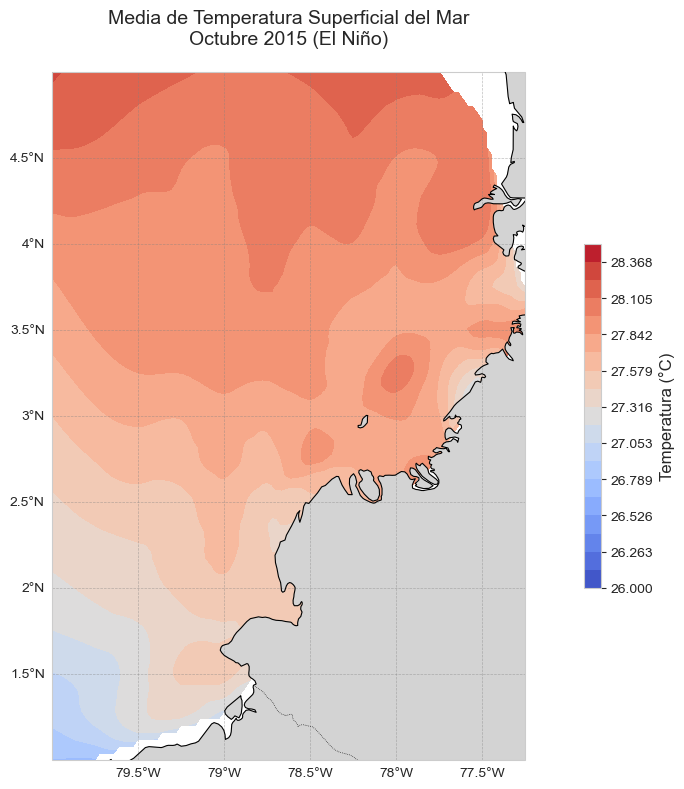

Guardado: C:\Users\danna\INSTRUGEO\MediaTSMM_2015_El_Nino.png


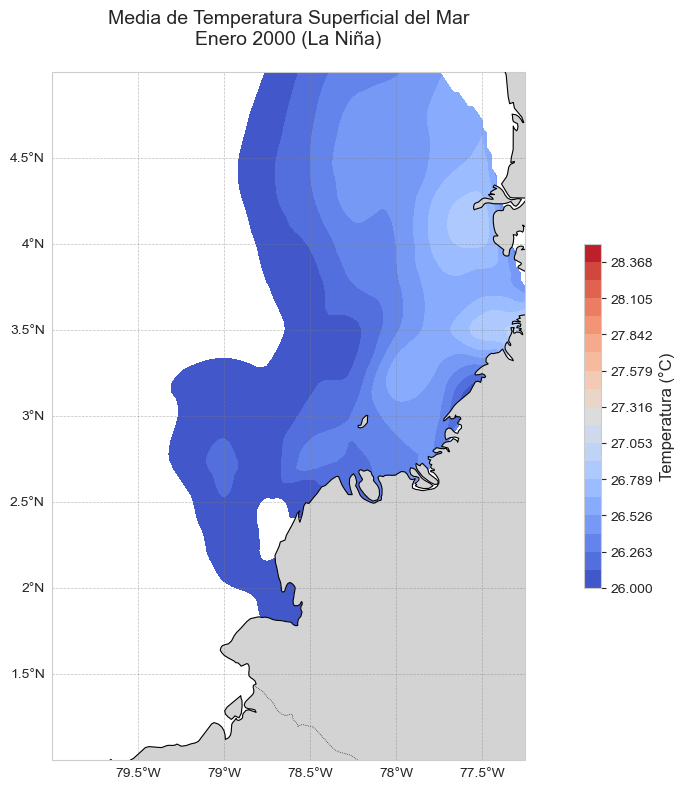

Guardado: C:\Users\danna\INSTRUGEO\MediaTSMM_2000_La_Nina.png


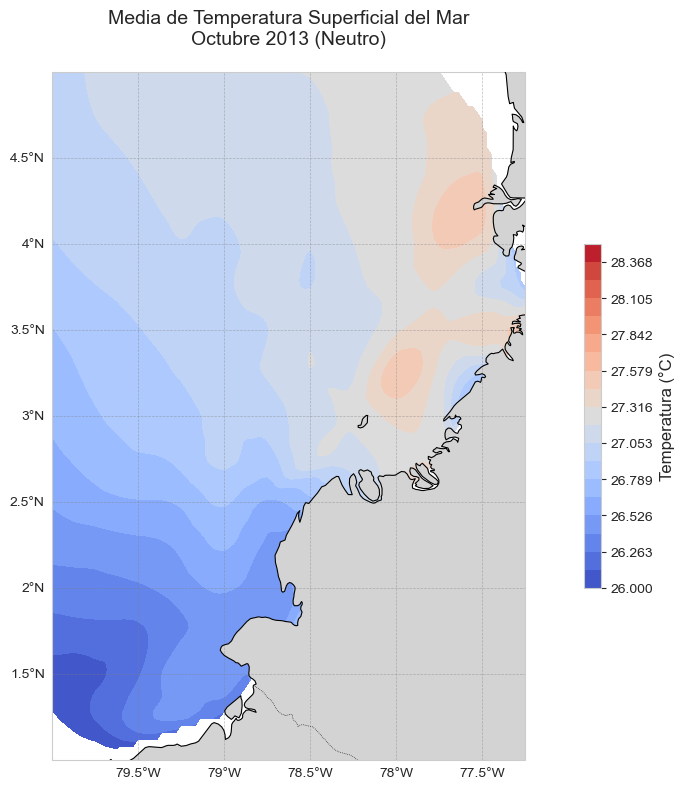

Guardado: C:\Users\danna\INSTRUGEO\MediaTSMM_2013_Neutro.png


In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def create_contour_map(year_data, year, category, phase, mes):
    """Crea un mapa de contornos de TSM con tierra encima y escala fija."""
    
    # Limpiar los datos quitando valores vacíos
    year_data_clean = year_data.dropna(subset=['Media Temperatura'])
    
    lons = year_data_clean['Longitude'].values
    lats = year_data_clean['Latitude'].values
    temps = year_data_clean['Media Temperatura'].values

    # Crear una malla más fina para suavizar el mapa
    lon_grid = np.linspace(min(lons), max(lons), 100)
    lat_grid = np.linspace(min(lats), max(lats), 100)
    lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

    # Interpolar los datos sobre la malla
    temp_grid = griddata((lons, lats), temps, (lon_mesh, lat_mesh), method='cubic')

    # Crear figura y eje del mapa
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Mapa de contornos rellenos
    contour = ax.contourf(
        lon_mesh,
        lat_mesh,
        temp_grid,
        levels=np.linspace(26, 28.5, 20),   # escala fija
        transform=ccrs.PlateCarree(),
        cmap='coolwarm',
        zorder=1
    )

    # Agregar tierra para tapar la temperatura sobre continente
    ax.add_feature(
        cfeature.LAND,
        zorder=2,
        color='lightgray',
        edgecolor='black',
        linewidth=0.3
    )

    # Línea de costa y fronteras
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5, zorder=3)

    # Barra de color
    cbar = plt.colorbar(contour, shrink=0.5, orientation='vertical', pad=0.05)
    cbar.set_label('Temperatura (°C)', fontsize=12)

    # Ajustar extensión del mapa
    margin = 0.0 * max((max(lons) - min(lons)), (max(lats) - min(lats)))
    ax.set_extent([
        min(lons) - margin,
        max(lons) + margin,
        min(lats) - margin,
        max(lats) + margin
    ], crs=ccrs.PlateCarree())

    # Cuadrícula con etiquetas
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.5,
        color='gray',
        alpha=0.5,
        linestyle='--',
        zorder=1
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}

    # Título
    plt.title(
        f'Media de Temperatura Superficial del Mar\n{mes} {year} ({category})',
        fontsize=14,
        pad=20
    )

    plt.tight_layout()
    return fig


# ======================
# Generación de gráficos
# ======================

# Diccionario con años y categorías
year_categories = {
    2015: ('El Niño', 'Fase cálida', 'Octubre', 10),
    2000: ('La Niña', 'Fase fría', 'Enero', 1),
    2013: ('Neutro', 'Fase Neutra', 'Octubre', 10),
}

# Ruta donde quieres guardar las imágenes
output_folder = r"C:\Users\danna\INSTRUGEO"

# Recorrer cada año para crear y guardar su mapa
for year, (category, phase, mes, nmes) in year_categories.items():

    # Filtrar datos del año y mes
    year_data = latlonyly_means[
        (latlonyly_means['Year'] == year) &
        (latlonyly_means['Month'] == nmes)
    ].dropna(subset=['Media Temperatura'])

    # Verificar que sí haya datos
    if year_data.empty:
        print(f"No hay datos para {mes} de {year} ({category})")
        continue

    # Crear la figura
    fig = create_contour_map(year_data, year, category, phase, mes)

    # Crear un nombre de archivo seguro
    nombre_categoria = category.replace(" ", "_").replace("ñ", "n")
    file_path = fr"{output_folder}\MediaTSMM_{year}_{nombre_categoria}.png"

    # Guardar la figura
    fig.savefig(file_path, dpi=300, bbox_inches='tight')

    # Mostrar en pantalla
    plt.show()

    # Cerrar la figura para liberar memoria
    plt.close(fig)

    print(f"Guardado: {file_path}")

In [19]:
for year, (category, phase, mes, nmes) in year_categories.items():
    # Filtrar los datos solo para el año y mes que estoy analizando
    year_data = latlonyly_means[(latlonyly_means['Year'] == year) &
        (latlonyly_means['Month'] == nmes) ]
    # Quitar valores nulos por si hay datos faltantes
    year_data = year_data.dropna(subset=['Media Temperatura'])
    # Esto realmente es redundante pero lo dejo por seguridad
    year_data_clean = year_data.dropna(subset=['Media Temperatura'])
    # Extraer longitudes, latitudes y temperaturas en arrays
    lons = year_data_clean['Longitude'].values
    lats = year_data_clean['Latitude'].values
    temps = year_data_clean['Media Temperatura'].values
    # Crear una malla de coordenadas más densa para interpolar
    lon_grid = np.linspace(min(lons), max(lons), 100)
    lat_grid = np.linspace(min(lats), max(lats), 100)
    # Crear la grilla 2D (tipo rejilla para el mapa)
    lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)
    # Imprimir los datos filtrados para revisar que todo esté bien
    print(year_data)
    # Imprimir coordenadas y temperaturas para ver qué valores está usando
    print("LONS, LATS. TEMPS", lons, lats, temps)

       Year  Month  Longitude  Latitude  Media Temperatura
47073  2015     10     -80.00      1.00          26.784114
47074  2015     10     -80.00      1.25          26.948493
47075  2015     10     -80.00      1.50          27.046085
47076  2015     10     -80.00      1.75          27.180472
47077  2015     10     -80.00      2.00          27.287264
...     ...    ...        ...       ...                ...
47255  2015     10     -77.50      4.00          27.932676
47257  2015     10     -77.50      4.50          28.054340
47258  2015     10     -77.50      4.75          28.034744
47270  2015     10     -77.25      3.50          28.071946
47271  2015     10     -77.25      3.75          27.372288

[144 rows x 5 columns]
LONS, LATS. TEMPS [-80.   -80.   -80.   -80.   -80.   -80.   -80.   -80.   -80.   -80.
 -80.   -80.   -80.   -80.   -80.   -80.   -80.   -79.75 -79.75 -79.75
 -79.75 -79.75 -79.75 -79.75 -79.75 -79.75 -79.75 -79.75 -79.75 -79.75
 -79.75 -79.75 -79.75 -79.75 -79.5  -79


📅 2015 - Octubre (El Niño):
       Year  Month  Longitude  Latitude  Media Temperatura
47073  2015     10      -80.0      1.00          26.784114
47074  2015     10      -80.0      1.25          26.948493
47075  2015     10      -80.0      1.50          27.046085
47076  2015     10      -80.0      1.75          27.180472
47077  2015     10      -80.0      2.00          27.287264
...     ...    ...        ...       ...                ...
47289  2015     10      -77.0      4.00                NaN
47290  2015     10      -77.0      4.25                NaN
47291  2015     10      -77.0      4.50                NaN
47292  2015     10      -77.0      4.75                NaN
47293  2015     10      -77.0      5.00                NaN

[221 rows x 5 columns]


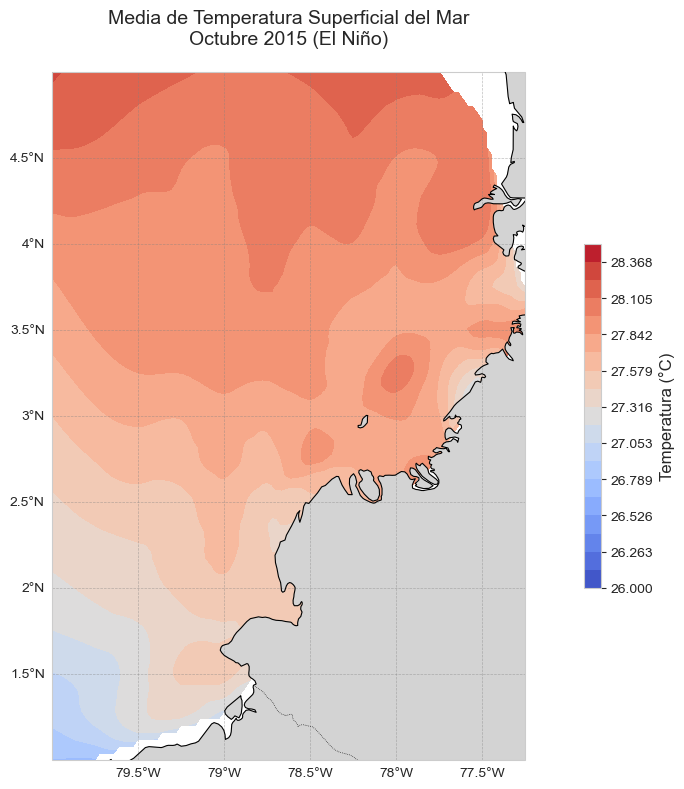


📅 2000 - Enero (La Niña):
      Year  Month  Longitude  Latitude  Media Temperatura
5304  2000      1      -80.0      1.00          25.473629
5305  2000      1      -80.0      1.25          25.574152
5306  2000      1      -80.0      1.50          25.607103
5307  2000      1      -80.0      1.75          25.647931
5308  2000      1      -80.0      2.00          25.641631
...    ...    ...        ...       ...                ...
5520  2000      1      -77.0      4.00                NaN
5521  2000      1      -77.0      4.25                NaN
5522  2000      1      -77.0      4.50                NaN
5523  2000      1      -77.0      4.75                NaN
5524  2000      1      -77.0      5.00                NaN

[221 rows x 5 columns]


<Figure size 640x480 with 0 Axes>

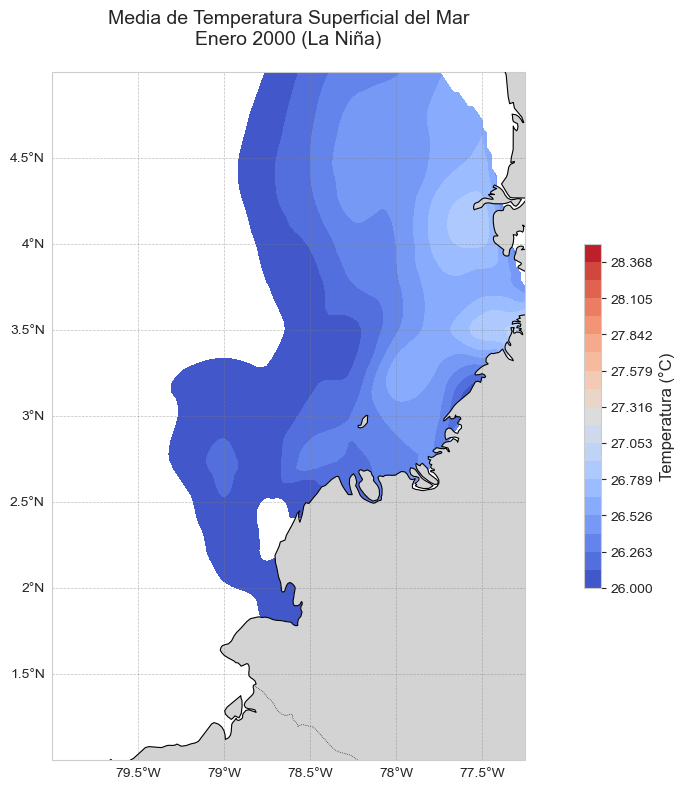


📅 2013 - Octubre (Neutro):
       Year  Month  Longitude  Latitude  Media Temperatura
41769  2013     10      -80.0      1.00          25.788634
41770  2013     10      -80.0      1.25          25.984671
41771  2013     10      -80.0      1.50          26.081476
41772  2013     10      -80.0      1.75          26.204995
41773  2013     10      -80.0      2.00          26.332578
...     ...    ...        ...       ...                ...
41985  2013     10      -77.0      4.00                NaN
41986  2013     10      -77.0      4.25                NaN
41987  2013     10      -77.0      4.50                NaN
41988  2013     10      -77.0      4.75                NaN
41989  2013     10      -77.0      5.00                NaN

[221 rows x 5 columns]


<Figure size 640x480 with 0 Axes>

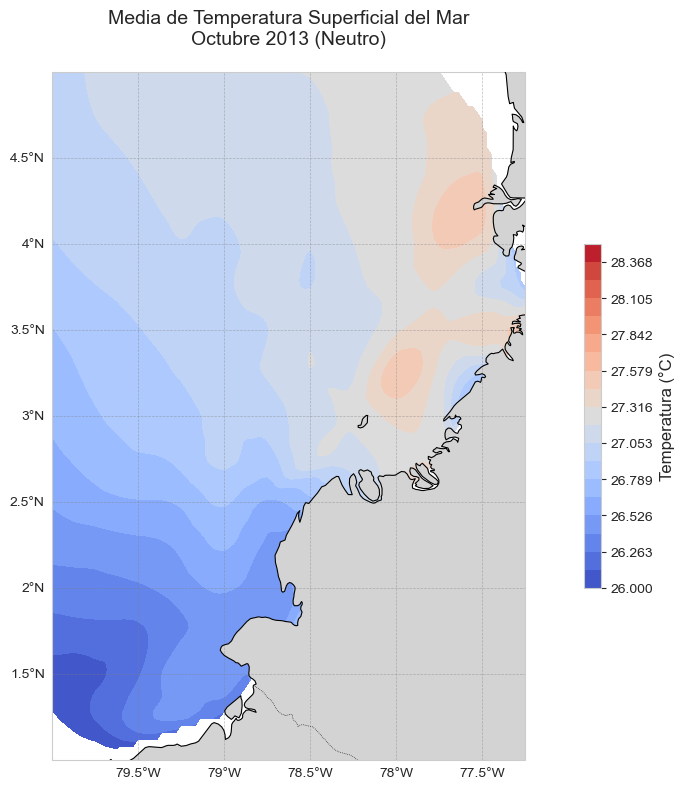

<Figure size 640x480 with 0 Axes>

In [39]:
for year, (category, phase, mes, nmes) in year_categories.items():
    year_data = latlonyly_means[
        (latlonyly_means['Year'] == year) &
        (latlonyly_means['Month'] == nmes)
    ]

    print(f"\n📅 {year} - {mes} ({category}):")
    print(year_data)

    fig = create_contour_map(year_data, year, category, phase, mes)
    plt.show()
    plt.savefig("NiñoNiñaNeutro")

In [22]:
for year, values in year_categories.items(): 
    # Check if we have all 4 expected values
    if len(values) == 4:
        category, phase, month_name, month_number = values
    else:
        # Handle the case where we only have 3 values
        # You might need to adjust this based on your actual data structure
        category, phase, month_name = values
        month_number = None  # Or some default value
    
    # Only proceed if we have a valid month_number
    if month_number is not None:
        # Filtrar los datos para quedarme solo con el año y mes que estoy analizando
        year_month_data = latlonyly_means[
            (latlonyly_means['Year'] == year) & (latlonyly_means['Month'] == month_number)
        ]
        
        # Imprimir un encabezado para saber qué estoy viendo
        print(f"\n--- {year} | Categoría: {category} | Fase: {phase} | Mes: {month_name} ({month_number}) ---")
        
        # Mostrar las primeras filas para revisar que los datos sí están bien filtrados
        print(year_month_data.head(20))


--- 2015 | Categoría: El Niño | Fase: Fase cálida | Mes: Octubre (10) ---
       Year  Month  Longitude  Latitude  Media Temperatura
47073  2015     10     -80.00      1.00          26.784114
47074  2015     10     -80.00      1.25          26.948493
47075  2015     10     -80.00      1.50          27.046085
47076  2015     10     -80.00      1.75          27.180472
47077  2015     10     -80.00      2.00          27.287264
47078  2015     10     -80.00      2.25          27.354993
47079  2015     10     -80.00      2.50          27.426125
47080  2015     10     -80.00      2.75          27.508659
47081  2015     10     -80.00      3.00          27.577112
47082  2015     10     -80.00      3.25          27.665887
47083  2015     10     -80.00      3.50          27.760867
47084  2015     10     -80.00      3.75          27.828279
47085  2015     10     -80.00      4.00          27.897836
47086  2015     10     -80.00      4.25          28.000627
47087  2015     10     -80.00      4.50 

In [23]:
# Option 1: If all entries should have 4 values, check your year_categories dictionary
# and make sure each entry has all 4 values (category, phase, month_name, month_number)

# Option 2: If some entries legitimately have only 3 values, modify the loop to handle this:
for year, values in year_categories.items():
    # Check if we have all 4 expected values
    if len(values) == 4:
        category, phase, month_name, month_number = values
    elif len(values) == 3:
        # Adjust based on which value might be missing
        category, phase, month_name = values
        month_number = None  # Or provide a default value
    else:
        # Handle other cases or skip
        print(f"Skipping year {year} due to insufficient data")
        continue
    
    # Only proceed if we have a month number
    if month_number is not None:
        # filtro los datos para quedarme solo con el año y mes que quiero analizar
        year_month_data = latlonyly_means[
            (latlonyly_means['Year'] == year) & (latlonyly_means['Month'] == month_number)
        ]
        
        # imprimo un encabezado para ubicarme mejor en qué caso estoy
        print(f"\n--- {year} | Categoría: {category} | Fase: {phase} | Mes: {month_name} ({month_number}) ---")
        
        # muestro las primeras filas para ver que los datos sí están bien filtrados
        print(year_month_data.head(20))


--- 2015 | Categoría: El Niño | Fase: Fase cálida | Mes: Octubre (10) ---
       Year  Month  Longitude  Latitude  Media Temperatura
47073  2015     10     -80.00      1.00          26.784114
47074  2015     10     -80.00      1.25          26.948493
47075  2015     10     -80.00      1.50          27.046085
47076  2015     10     -80.00      1.75          27.180472
47077  2015     10     -80.00      2.00          27.287264
47078  2015     10     -80.00      2.25          27.354993
47079  2015     10     -80.00      2.50          27.426125
47080  2015     10     -80.00      2.75          27.508659
47081  2015     10     -80.00      3.00          27.577112
47082  2015     10     -80.00      3.25          27.665887
47083  2015     10     -80.00      3.50          27.760867
47084  2015     10     -80.00      3.75          27.828279
47085  2015     10     -80.00      4.00          27.897836
47086  2015     10     -80.00      4.25          28.000627
47087  2015     10     -80.00      4.50 

In [24]:
#ver en qué puntos del mapa tengo datos (sin repetirlos)
latlonyly_means[['Latitude', 'Longitude']].drop_duplicates()

,Latitude,Longitude
0,1.00,-80.0
1,1.25,-80.0
2,1.50,-80.0
3,1.75,-80.0
4,2.00,-80.0
...,...,...
216,4.00,-77.0
217,4.25,-77.0
218,4.50,-77.0
219,4.75,-77.0


In [35]:
data.head(5)

,Date,Latitude,Longitude,Sea surface t
0,1998-01-01 00:00,5.0,-80.00,28.12075
1,1998-01-01 00:00,5.0,-79.75,28.15493
2,1998-01-01 00:00,5.0,-79.50,28.22330
3,1998-01-01 00:00,5.0,-79.25,28.35122
4,1998-01-01 00:00,5.0,-79.00,28.38247


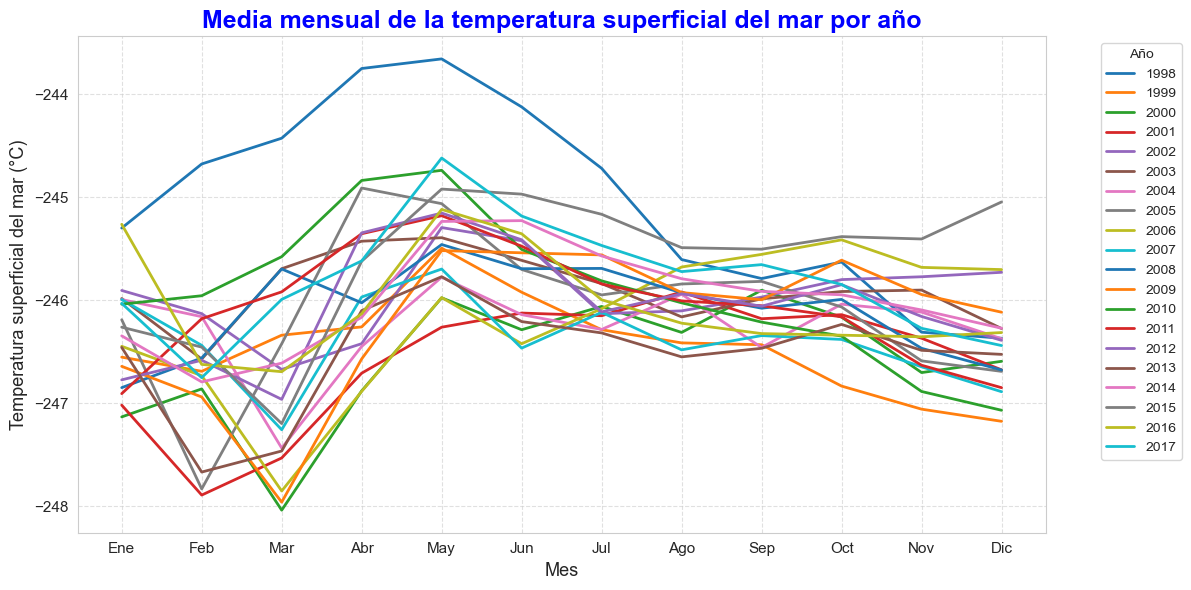

<Figure size 640x480 with 0 Axes>

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def graficar_media_mensual_por_anio(dataframeinput):
    try:
        # hacer una copia para no modificar el original
        df = dataframeinput.copy()

        # limpiar nombres de columnas por si tienen espacios extras
        df.columns = df.columns.str.strip()

        # convertir fecha a formato datetime
        df['Date'] = pd.to_datetime(df['Date'])

        # crear columnas de año y mes
        df['Year'] = df['Date'].dt.year
        df['Month'] = df['Date'].dt.month

        # convertir temperatura a numérica por si viene como texto
        df['Sea surface t'] = pd.to_numeric(df['Sea surface t'], errors='coerce')

        # pasar de Kelvin a Celsius
        df['Sea surface t'] = df['Sea surface t'] - 273.15

        # renombrar la columna para usar el nombre que espera la función
        df.rename(columns={'Sea surface t': 'Media Temperatura'}, inplace=True)

        # verificar columnas necesarias
        columnas_requeridas = {"Month", "Year", "Media Temperatura"}
        if not columnas_requeridas.issubset(df.columns):
            raise ValueError(f"El dataframe debe contener las columnas {columnas_requeridas}.")

        # agrupar por año y mes para sacar la media
        df_grouped = df.groupby(["Year", "Month"])["Media Temperatura"].mean().reset_index()

        # reorganizar datos: meses en eje x y años como líneas
        df_pivot = df_grouped.pivot(index="Month", columns="Year", values="Media Temperatura")

        # estilo de la gráfica
        sns.set_style("whitegrid")
        plt.figure(figsize=(12, 6))

        # graficar una línea por año
        for year in df_pivot.columns:
            plt.plot(df_pivot.index, df_pivot[year], label=str(year), linewidth=2)

        # título y etiquetas
        plt.title(
            "Media mensual de la temperatura superficial del mar por año",
            fontsize=18,
            color="blue",
            fontweight="bold"
        )
        plt.xlabel("Mes", fontsize=13)
        plt.ylabel("Temperatura superficial del mar (°C)", fontsize=13)

        # nombres de los meses
        plt.xticks(
            ticks=range(1, 13),
            labels=["Ene", "Feb", "Mar", "Abr", "May", "Jun",
                    "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"],
            fontsize=11
        )
        plt.yticks(fontsize=11)

        # leyenda
        plt.legend(title="Año", bbox_to_anchor=(1.05, 1), loc="upper left")

        # cuadrícula y ajuste final
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.tight_layout()

        # guardar imagen antes de mostrar
        plt.savefig("Media_mensual_TSM.png", dpi=300, bbox_inches="tight")

        # mostrar gráfica
        plt.show()

    except Exception as e:
        print(f"Error: {e}")

# ejecutar con tu dataframe original
graficar_media_mensual_por_anio(data)
plt.savefig("MediaMpaTSM")

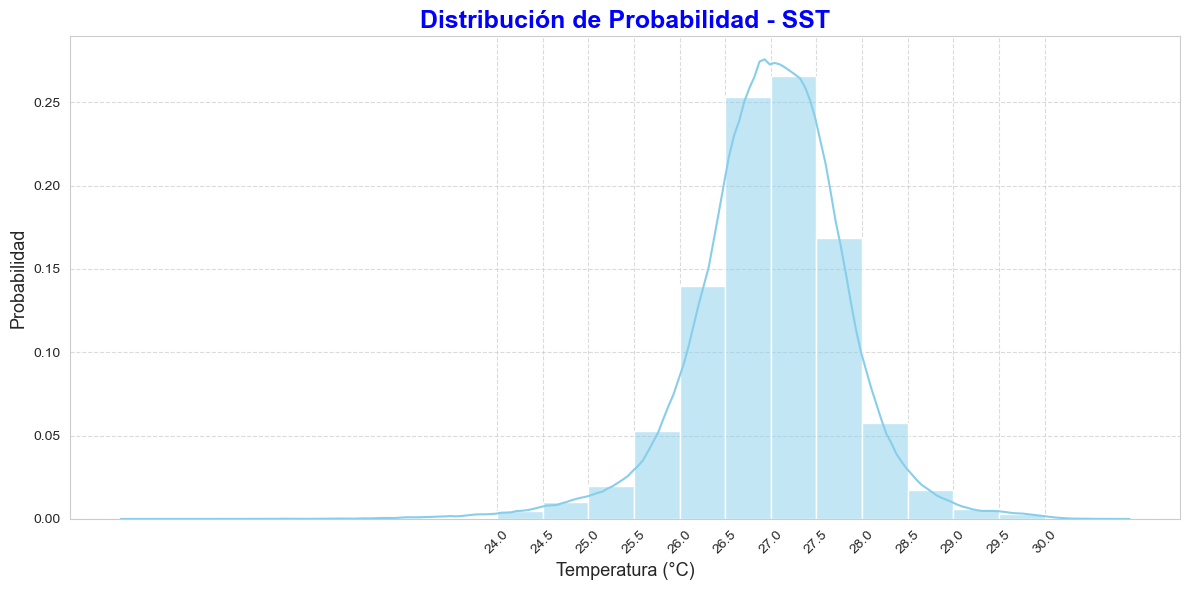

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Leer el archivo CSV con los datos diarios de temperatura
data = pd.read_csv(r"C:\Users\danna\INSTRUGEO\SST.csv")

# Asegurar que la columna de temperatura sea numérica
# si hay valores raros, los convierte en NaN
data['Sea surface t'] = pd.to_numeric(data['Sea surface t'], errors='coerce')

# Convertir de Kelvin a Celsius
# porque ERA5 normalmente viene en Kelvin
data['Sea surface t'] = data['Sea surface t'] - 273.15

# Guardar las temperaturas en una variable para trabajar más fácil
temperaturas = data['Sea surface t']

# Definir los bins (rangos de temperatura)
# básicamente cómo se agrupan los datos en el histograma
bins_personalizados = np.linspace(24, 30, 13)

# Crear la figura
plt.figure(figsize=(12, 6))

# Histograma + curva KDE (forma suave de la distribución)
ax = sns.histplot(
    temperaturas,
    kde=True,
    stat='probability',  # para que sea probabilidad y no frecuencia
    bins=bins_personalizados,
    color='skyblue'
)

# Ajustar los valores del eje X para que coincidan con los bins
plt.xticks(bins_personalizados)

# Rotar los números para que no se encimen
plt.xticks(rotation=45)

# Título mejorado 
plt.title(
    'Distribución de Probabilidad - SST',
    fontsize=18,
    color='blue',
    fontweight='bold'
)

# Etiquetas de los ejes
plt.xlabel('Temperatura (°C)', fontsize=13)
plt.ylabel('Probabilidad', fontsize=13)

# Activar grilla para que se vea más claro
plt.grid(True, linestyle='--', alpha=0.7)

# Ajustar el layout para que no se corten los labels
plt.tight_layout()
plt.savefig("1.png", dpi=300)
# Mostrar la gráfica
plt.show()


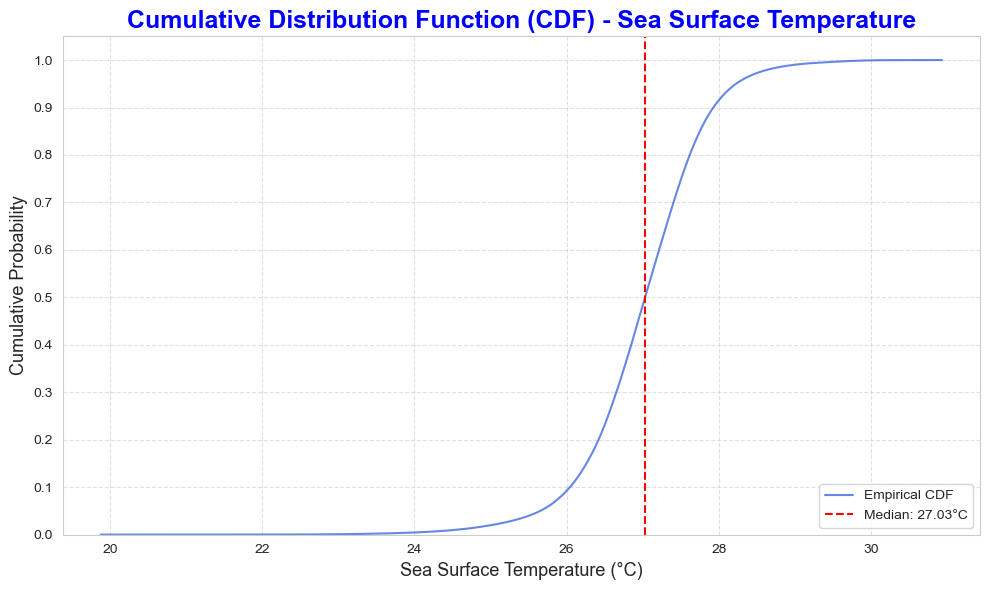

<Figure size 640x480 with 0 Axes>

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ordenar los datos de temperatura (quitando NaN por si hay datos dañados)
temperaturas_sorted = np.sort(temperaturas.dropna())

# calcular la CDF (probabilidad acumulada)
# básicamente qué tan probable es que la temperatura sea menor a cierto valor
cdf = np.arange(1, len(temperaturas_sorted) + 1) / len(temperaturas_sorted)

# usar un estilo más limpio para la gráfica
sns.set_style("whitegrid")

# crear figura
plt.figure(figsize=(10, 6))

# graficar la CDF
plt.plot(
    temperaturas_sorted, 
    cdf, 
    marker='',          # sin puntos, solo línea
    markersize=4,       
    linestyle='-',      # línea continua
    linewidth=1.5,      
    color='royalblue',  # azul más bonito
    alpha=0.8,          
    label='Empirical CDF'
)

# calcular la mediana (valor central de la distribución)
median_temp = np.median(temperaturas_sorted)

# dibujar una línea vertical en la mediana
plt.axvline(
    median_temp, 
    color='red', 
    linestyle='--', 
    linewidth=1.5,
    label=f'Median: {median_temp:.2f}°C'
)

# título mejorado (más grande, azul y en negrita)
plt.title(
    'Cumulative Distribution Function (CDF) - Sea Surface Temperature',
    fontsize=18,
    color='blue',
    fontweight='bold'
)

# etiquetas de ejes
plt.xlabel('Sea Surface Temperature (°C)', fontsize=13)
plt.ylabel('Cumulative Probability', fontsize=13)

# grilla para que se vea más claro
plt.grid(True, linestyle='--', alpha=0.6)

# leyenda
plt.legend(loc='lower right', fontsize=10)

# ajustar límites para que la gráfica se vea mejor
plt.xlim([temperaturas_sorted.min() - 0.5, temperaturas_sorted.max() + 0.5])
plt.ylim([0, 1.05])

# mejorar los ticks
plt.xticks(fontsize=10)
plt.yticks(np.arange(0, 1.1, 0.1), fontsize=10)

# ajustar márgenes para que no se corte nada
plt.tight_layout()

# guardar imagen si quieres
# plt.savefig('CDF_SST.png', dpi=300, bbox_inches='tight')

# mostrar gráfica
plt.show()

plt.savefig("CDistributionTSM")